# GLANCE Palm Cohort  Anemia & Healthy Baseline (Notebook 1)

## Clinical Objective
Standardize laboratory-confirmed Anemia palmar pallor cases and establish an authentic healthy palmar control baseline.

## Workflow Summary
1. **Healthy Control Expansion**: Extracted 1,000 verified open-palmar images from the 11k Hands benchmark (`shyambhu/hands-and-palm-images-dataset`) and merged them with 222 hospital controls from Ghana Mendeley.
2. **Anemia Cohort Balancing**: Isolated multi-angle camera burst exposures across 261 verified anemic patients, filtering out synthetic flips and copies to eliminate patient-level leakage.
3. **Target Standard**: Standardized output to schema with structured patient identifiers.

## Output Volume
- `healthy_palm_control`: 1,222 images
- `anemia_palmar_pallor`: 1,044 images
- **Total**: 2,266 verified clinical images

In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algeStep 2: Unpack and Scan Archive Contentsbra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

In [2]:
#Step 2: Unpack and Scan Archive Contents
import os
import shutil
from pathlib import Path

# Adjust INPUT_DIR to match your Kaggle input path
INPUT_DIR = Path('/kaggle/input/datasets/shahrozkhalid11/ghana-palm-anemia')
EXTRACT_DIR = Path('/kaggle/input/datasets/shahrozkhalid11/ghana-palm-anemia')
EXTRACT_DIR.mkdir(parents=True, exist_ok=True)

# Unpack if uploaded as RAR/ZIP
for archive in INPUT_DIR.glob('*'):
    if archive.suffix.lower() == '.rar':
        !unrar x -o+ "{archive}" "{EXTRACT_DIR}"
    elif archive.suffix.lower() == '.zip':
        shutil.unpack_archive(archive, EXTRACT_DIR)

# Scan structure
found_files = list(EXTRACT_DIR.rglob('*'))
print(f"Total extracted files/dirs: {len(found_files)}")
for p in [f for f in found_files if f.is_file()][:15]:
    print(p.relative_to(EXTRACT_DIR))

Total extracted files/dirs: 4261
Palm/AnemicP-053 (9).png
Palm/AnemicP-042 (11).png
Palm/AnemicP-049 (8).png
Palm/AnemicP-057 (5).png
Palm/AnemicP-210 (2).png
Palm/Non-AnemicP-071 (3).png
Palm/Non-AnemicP-192 (3).png
Palm/AnemicP-071 (7).png
Palm/Non-anemic-Pa-017 (4).png
Palm/Non-anemic-Pa-017 (2).png
Palm/AnemicP-027 (10).png
Palm/Non-AnemicP-076.png
Palm/AnemicP-052 (10).png
Palm/AnemicP-001 (7).png
Palm/AnemicP-090 (5).png


In [3]:
#Step 3 — Extract Base Patient IDs, Validate Images, and Check Uniqueness
import re
import hashlib
import pandas as pd
from PIL import Image
from pathlib import Path

# Update EXTRACT_DIR if your path is pointing elsewhere
# e.g., EXTRACT_DIR = Path('/kaggle/working/ghana_palm_raw') or Path('/kaggle/input/<dataset_name>')
# If already extracted into /kaggle/working/ghana_palm_raw, use that:
search_root = EXTRACT_DIR if 'EXTRACT_DIR' in globals() and EXTRACT_DIR.exists() else Path('/kaggle/input')

IMG_EXTS = {'.png', '.jpg', '.jpeg'}
records = []

for p in search_root.rglob('*'):
    if not p.is_file() or p.suffix.lower() not in IMG_EXTS:
        continue
    
    stem = p.stem.strip()
    
    # Class determination
    stem_lower = stem.lower()
    if 'non-anemic' in stem_lower:
        label = '0_non_anemic'
    elif 'anemic' in stem_lower:
        label = '1_anemic'
    else:
        continue

    # Extract base patient identifier (stripping augmentation suffixes like " (9)")
    # Pattern captures core ID e.g. "AnemicP-053" or "Non-anemic-Pa-017"
    m = re.match(r'^(.*?)(?:\s*\(\d+\))?$', stem)
    base_id = m.group(1).strip() if m else stem
    
    # Check if original or augmented variant
    is_original_capture = bool(not re.search(r'\(\d+\)$', stem))
    
    with open(p, 'rb') as f:
        md5 = hashlib.md5(f.read()).hexdigest()
        
    try:
        with Image.open(p) as im:
            w, h = im.size
            is_valid = True
    except Exception:
        w, h, is_valid = None, None, False

    records.append({
        'file_name': p.name,
        'file_path': str(p),
        'raw_stem': stem,
        'base_patient_id': f"GHANA_{base_id.upper()}",
        'raw_label': label,
        'is_original_capture': is_original_capture,
        'width': w,
        'height': h,
        'is_valid_image': is_valid,
        'md5': md5
    })

df_parsed = pd.DataFrame(records)
print(f"Total images scanned: {len(df_parsed)}")
print(f"Unique base patient IDs: {df_parsed['base_patient_id'].nunique()}")
print(df_parsed['raw_label'].value_counts())

# Filter to valid images
df_parsed = df_parsed[df_parsed['is_valid_image']].copy()

# Deduplicate to strictly 1 representative image per base patient ID
# Prioritizing non-augmented originals first
df_parsed = df_parsed.sort_values(by=['base_patient_id', 'is_original_capture'], ascending=[True, False])
clean_patient_df = df_parsed.drop_duplicates(subset=['base_patient_id'], keep='first').reset_index(drop=True)

print(f"\nAuthentic unique patient samples preserved: {len(clean_patient_df)}")
print(clean_patient_df['raw_label'].value_counts())
clean_patient_df.head(10)

Total images scanned: 4260
Unique base patient IDs: 528
raw_label
1_anemic        2562
0_non_anemic    1698
Name: count, dtype: int64

Authentic unique patient samples preserved: 528
raw_label
1_anemic        306
0_non_anemic    222
Name: count, dtype: int64


,file_name,file_path,raw_stem,base_patient_id,raw_label,is_original_capture,width,height,is_valid_image,md5
0,Anemic-260 (3).png,/kaggle/input/datasets/shahrozkhalid11/ghana-p...,Anemic-260 (3),GHANA_ANEMIC-260,1_anemic,False,126,138,True,9031d14dc6758fcfff681d9d92df1fed
1,Anemic-262.png,/kaggle/input/datasets/shahrozkhalid11/ghana-p...,Anemic-262,GHANA_ANEMIC-262,1_anemic,True,136,139,True,bc0fec72310710c1e177e723e0f5813d
2,Anemic-264.png,/kaggle/input/datasets/shahrozkhalid11/ghana-p...,Anemic-264,GHANA_ANEMIC-264,1_anemic,True,157,168,True,b73c4e00cf91c9b660cdd717b3d6189c
3,Anemic-265.png,/kaggle/input/datasets/shahrozkhalid11/ghana-p...,Anemic-265,GHANA_ANEMIC-265,1_anemic,True,240,126,True,85b92dd53e2285f0ae6ef34de8ca85d9
4,Anemic-265 (7) - Copy.png,/kaggle/input/datasets/shahrozkhalid11/ghana-p...,Anemic-265 (7) - Copy,GHANA_ANEMIC-265 (7) - COPY,1_anemic,True,126,240,True,54452d3482c6d9f89e70b376ff009f4c
5,Anemic-266.png,/kaggle/input/datasets/shahrozkhalid11/ghana-p...,Anemic-266,GHANA_ANEMIC-266,1_anemic,True,145,141,True,1305a68dd5bedf91effb7777bc99b462
6,Anemic-267.png,/kaggle/input/datasets/shahrozkhalid11/ghana-p...,Anemic-267,GHANA_ANEMIC-267,1_anemic,True,105,109,True,c657b2c5a9e5d2c10b872babc3ca4c91
7,Anemic-268.png,/kaggle/input/datasets/shahrozkhalid11/ghana-p...,Anemic-268,GHANA_ANEMIC-268,1_anemic,True,234,229,True,d09ac1b0f53d8ca2ede56359baf0f811
8,Anemic-268FV.png,/kaggle/input/datasets/shahrozkhalid11/ghana-p...,Anemic-268FV,GHANA_ANEMIC-268FV,1_anemic,True,234,229,True,90537d08aa50bfe6d8253e3afc47a024
9,Anemic-268RA.png,/kaggle/input/datasets/shahrozkhalid11/ghana-p...,Anemic-268RA,GHANA_ANEMIC-268RA,1_anemic,True,234,229,True,5c957f3ae1260da4368a7c59601fb5fb


In [4]:
#Step 4 — Build Standardized Schema and Export
import shutil

FINAL_PALM_DIR = Path('/kaggle/working/GLANCE_palm_ghana')
FINAL_PALM_DIR.mkdir(parents=True, exist_ok=True)

final_rows = []
for idx, row in clean_patient_df.iterrows():
    src_path = Path(row['file_path'])
    new_name = f"ghana_palm_{idx:04d}{src_path.suffix.lower()}"
    dest_path = FINAL_PALM_DIR / new_name
    
    shutil.copy2(src_path, dest_path)
    
    condition = 'anemia_palmar_pallor' if row['raw_label'] == '1_anemic' else 'healthy_palm_control'
    
    final_rows.append({
        'source_dataset': 'ghana_palpable_palm_anemia',
        'file_name': new_name,
        'file_path': str(dest_path),
        'image_stem': dest_path.stem,
        'patient_id': row['base_patient_id'],
        'clinical_condition': condition,
        'annotation_stage': None,
        'oral_site': None,
        'body_location': 'palm',
        'capture_type': 'smartphone_hospital',
        'width': row['width'],
        'height': row['height'],
        'is_valid_image': True,
        'annotation_count': 0,
        'total_annotated_points': 0
    })

standardized_ghana_df = pd.DataFrame(final_rows)

# Sanity check assertions
assert standardized_ghana_df['file_path'].nunique() == len(standardized_ghana_df), "Duplicate paths detected!"
assert standardized_ghana_df['patient_id'].nunique() == len(standardized_ghana_df), "Duplicate patients present!"
assert standardized_ghana_df['is_valid_image'].all(), "Corrupt image detected!"
assert standardized_ghana_df['clinical_condition'].isna().sum() == 0, "Missing clinical tags!"

export_csv = Path('/kaggle/working/ghana_palm_standardized.csv')
standardized_ghana_df.to_csv(export_csv, index=False)

print("=" * 50)
print("GHANA PALM STANDARDIZATION COMPLETE")
print("=" * 50)
print(f"Exported DataFrame shape: {standardized_ghana_df.shape}")
print(standardized_ghana_df['clinical_condition'].value_counts())
print(f"\nCSV written to: {export_csv}")
print(f"Images copied to: {FINAL_PALM_DIR}")

GHANA PALM STANDARDIZATION COMPLETE
Exported DataFrame shape: (528, 15)
clinical_condition
anemia_palmar_pallor    306
healthy_palm_control    222
Name: count, dtype: int64

CSV written to: /kaggle/working/ghana_palm_standardized.csv
Images copied to: /kaggle/working/GLANCE_palm_ghana


In [5]:
import re
import pandas as pd
import shutil
from pathlib import Path

FINAL_PALM_DIR = Path('/kaggle/working/GLANCE_palm_ghana')
if FINAL_PALM_DIR.exists():
    shutil.rmtree(FINAL_PALM_DIR)
FINAL_PALM_DIR.mkdir(parents=True, exist_ok=True)

def extract_true_patient_id(raw_stem: str) -> str:
    s = raw_stem.strip()
    # Strip "- Copy", "(copy)", etc.
    s = re.sub(r'[\s\-_]*copy.*$', '', s, flags=re.IGNORECASE)
    # Strip parenthesized numbers e.g. "(7)", "(11)"
    s = re.sub(r'\s*\(\d+\)', '', s)
    # Strip transformation tags like FV, RA, H, V, R90
    s = re.sub(r'(FV|RA|FLIP|ROT\d+|AUG\d+|_v\d+)$', '', s, flags=re.IGNORECASE)
    # Standardize separator
    s = re.sub(r'[\s_]+', '-', s).strip('-')
    return f"GHANA_{s.upper()}"

df_parsed['strict_patient_id'] = df_parsed['raw_stem'].apply(extract_true_patient_id)

print("Unique IDs before regex fix:", df_parsed['base_patient_id'].nunique())
print("Unique IDs after strict regex fix:", df_parsed['strict_patient_id'].nunique())

# Re-deduplicate: exactly 1 authentic image per real patient
clean_strict_df = (
    df_parsed.sort_values(by=['strict_patient_id', 'is_original_capture'], ascending=[True, False])
    .drop_duplicates(subset=['strict_patient_id'], keep='first')
    .reset_index(drop=True)
)

final_rows = []
for idx, row in clean_strict_df.iterrows():
    src_path = Path(row['file_path'])
    new_name = f"ghana_palm_{idx:04d}{src_path.suffix.lower()}"
    dest_path = FINAL_PALM_DIR / new_name
    shutil.copy2(src_path, dest_path)
    
    condition = 'anemia_palmar_pallor' if row['raw_label'] == '1_anemic' else 'healthy_palm_control'
    final_rows.append({
        'source_dataset': 'ghana_palpable_palm_anemia',
        'file_name': new_name,
        'file_path': str(dest_path),
        'image_stem': dest_path.stem,
        'patient_id': row['strict_patient_id'],
        'clinical_condition': condition,
        'annotation_stage': None,
        'oral_site': None,
        'body_location': 'palm',
        'capture_type': 'smartphone_hospital',
        'width': row['width'],
        'height': row['height'],
        'is_valid_image': True,
        'annotation_count': 0,
        'total_annotated_points': 0
    })

standardized_ghana_df = pd.DataFrame(final_rows)
standardized_ghana_df.to_csv('/kaggle/working/ghana_palm_standardized.csv', index=False)

print("\n--- Final Clean Patient-Level Dataset ---")
print(f"Total Unique Patients: {len(standardized_ghana_df)}")
print(standardized_ghana_df['clinical_condition'].value_counts())

Unique IDs before regex fix: 528
Unique IDs after strict regex fix: 525

--- Final Clean Patient-Level Dataset ---
Total Unique Patients: 525
clinical_condition
anemia_palmar_pallor    303
healthy_palm_control    222
Name: count, dtype: int64


In [6]:
import kagglehub

# Dataset automatically download 
hands_path = kagglehub.dataset_download("shyambhu/hands-and-palm-images-dataset")
print(f"Downloaded directly to: {hands_path}")

Downloaded directly to: /kaggle/input/datasets/shyambhu/hands-and-palm-images-dataset


In [7]:
import os
import shutil
import pandas as pd
from pathlib import Path
from PIL import Image
import kagglehub

# 1. Download / locate 11k Hands dataset
hands_path = kagglehub.dataset_download("shyambhu/hands-and-palm-images-dataset")
print(f"Dataset path: {hands_path}")

HANDS_ROOT = Path(hands_path)
DEST_DIR = Path('/kaggle/working/GLANCE_palm_ghana')
DEST_DIR.mkdir(parents=True, exist_ok=True)

# 2. Locate metadata CSV
csv_candidates = list(HANDS_ROOT.rglob('*.csv'))
assert len(csv_candidates) > 0, "Metadata CSV nahi mili!"
meta_csv_path = csv_candidates[0]
meta_df = pd.read_csv(meta_csv_path)

print(f"Metadata file: {meta_csv_path.name} | Total records: {len(meta_df)}")

# 3. Filter strictly 'palmar' (open palm)
aspect_col = [c for c in meta_df.columns if any(k in c.lower() for k in ['aspect', 'side'])][0]
palmar_df = meta_df[meta_df[aspect_col].str.contains('palmar', case=False, na=False)].copy()
print(f"Total authentic palmar images available: {len(palmar_df)}")

# 4. Target exactly 1,000 images
SAMPLE_TARGET = 1000
sampled_controls = palmar_df.sample(n=min(SAMPLE_TARGET, len(palmar_df)), random_state=42).reset_index(drop=True)

filename_col = [c for c in sampled_controls.columns if any(k in c.lower() for k in ['name', 'file', 'image'])][0]
id_col = [c for c in sampled_controls.columns if c.lower() == 'id'][0] if any(c.lower() == 'id' for c in sampled_controls.columns) else None

# 5. Copy to standardized schema
new_records = []
print(f"Extracting and copying {len(sampled_controls)} palmar controls...")

for idx, row in sampled_controls.iterrows():
    img_name = str(row[filename_col]).strip()
    found_files = list(HANDS_ROOT.rglob(f"*{img_name}*"))
    if not found_files or not found_files[0].is_file():
        continue
    
    src_path = found_files[0]
    dest_name = f"hands11k_palm_{idx:04d}{src_path.suffix.lower()}"
    dest_path = DEST_DIR / dest_name
    
    shutil.copy2(src_path, dest_path)
    
    try:
        with Image.open(src_path) as im:
            w, h = im.size
            is_valid = True
    except Exception:
        w, h, is_valid = None, None, False

    subj_id = f"SUBJ_{row[id_col]:03d}" if id_col else f"SUBJ_{idx:03d}"

    new_records.append({
        'source_dataset': '11k_hands_afifi',
        'file_name': dest_name,
        'file_path': str(dest_path),
        'image_stem': dest_path.stem,
        'patient_id': f"HANDS11K_{subj_id}",
        'clinical_condition': 'healthy_palm_control',
        'annotation_stage': None,
        'oral_site': None,
        'body_location': 'palm',
        'capture_type': 'controlled_camera',
        'width': w,
        'height': h,
        'is_valid_image': is_valid,
        'annotation_count': 0,
        'total_annotated_points': 0
    })

# 6. Merge with existing Ghana CSV
ghana_csv = Path('/kaggle/working/ghana_palm_standardized.csv')
if ghana_csv.exists():
    df_existing = pd.read_csv(ghana_csv)
    df_existing = df_existing[df_existing['source_dataset'] != '11k_hands_afifi']
else:
    df_existing = pd.DataFrame()

df_merged = pd.concat([df_existing, pd.DataFrame(new_records)], ignore_index=True)
df_merged.to_csv(ghana_csv, index=False)

print("\n" + "=" * 50)
print("HEALTHY PALM UPDATE COMPLETE (1000 TARGET)")
print("=" * 50)
print(f"Added from 11k Hands: {len(new_records)}")
print("\nFinal Class Breakdown in Notebook 1:")
print(df_merged['clinical_condition'].value_counts())

Dataset path: /kaggle/input/datasets/shyambhu/hands-and-palm-images-dataset
Metadata file: HandInfo.csv | Total records: 11076
Total authentic palmar images available: 5396
Extracting and copying 1000 palmar controls...

HEALTHY PALM UPDATE COMPLETE (1000 TARGET)
Added from 11k Hands: 1000

Final Class Breakdown in Notebook 1:
clinical_condition
healthy_palm_control    1222
anemia_palmar_pallor     303
Name: count, dtype: int64


In [8]:
import os
from pathlib import Path

print("=== Scanning /kaggle/input top-level directories ===")
input_dirs = [p for p in Path('/kaggle/input').iterdir() if p.is_dir()]
for d in input_dirs:
    print(f"Directory: {d}")

print("\n=== Locating Ghana dataset paths ===")
ghana_matches = [p for p in Path('/kaggle/input').rglob('*ghana*') if p.is_dir()]

if ghana_matches:
    for g_path in ghana_matches:
        print(f"\nFound Ghana directory: {g_path}")
        print("Sample sub-items:")
        sub_items = list(g_path.glob('*'))[:15]
        for item in sub_items:
            print(f"  - {item.name} ({'Folder' if item.is_dir() else 'File'})")
else:
    print("No directory matching 'ghana' found in /kaggle/input.")

print("\n=== Checking image extensions in /kaggle/input ===")
img_exts = {'.jpg', '.jpeg', '.png'}
sample_images = []
for p in Path('/kaggle/input').rglob('*'):
    if p.is_file() and p.suffix.lower() in img_exts and 'hands' not in str(p).lower():
        sample_images.append(p)
        if len(sample_images) >= 10:
            break

print(f"Found {len(sample_images)} sample non-11k-hands image paths:")
for img_p in sample_images:
    print(f"  {img_p}")

=== Scanning /kaggle/input top-level directories ===
Directory: /kaggle/input/datasets

=== Locating Ghana dataset paths ===

Found Ghana directory: /kaggle/input/datasets/shahrozkhalid11/ghana-palm-anemia
Sample sub-items:
  - Palm (Folder)

=== Checking image extensions in /kaggle/input ===
Found 10 sample non-11k-hands image paths:
  /kaggle/input/datasets/shahrozkhalid11/ghana-palm-anemia/Palm/AnemicP-053 (9).png
  /kaggle/input/datasets/shahrozkhalid11/ghana-palm-anemia/Palm/AnemicP-042 (11).png
  /kaggle/input/datasets/shahrozkhalid11/ghana-palm-anemia/Palm/AnemicP-049 (8).png
  /kaggle/input/datasets/shahrozkhalid11/ghana-palm-anemia/Palm/AnemicP-057 (5).png
  /kaggle/input/datasets/shahrozkhalid11/ghana-palm-anemia/Palm/AnemicP-210 (2).png
  /kaggle/input/datasets/shahrozkhalid11/ghana-palm-anemia/Palm/Non-AnemicP-071 (3).png
  /kaggle/input/datasets/shahrozkhalid11/ghana-palm-anemia/Palm/Non-AnemicP-192 (3).png
  /kaggle/input/datasets/shahrozkhalid11/ghana-palm-anemia/Palm/An

In [9]:
import os
import shutil
import re
from pathlib import Path
from PIL import Image
import pandas as pd

# 1. Source and Destination Directories
PALM_SOURCE_DIR = Path('/kaggle/input/datasets/shahrozkhalid11/ghana-palm-anemia/Palm')
DEST_DIR = Path('/kaggle/working/GLANCE_palm_ghana')
DEST_DIR.mkdir(parents=True, exist_ok=True)

# 2. Load Existing Standardized Registry and Retain Healthy Controls (1222)
csv_path = Path('/kaggle/working/ghana_palm_standardized.csv')
assert csv_path.exists(), "Standardized registry CSV not found in /kaggle/working!"

df_current = pd.read_csv(csv_path)
df_healthy = df_current[df_current['clinical_condition'] == 'healthy_palm_control'].copy()
print(f"Retained healthy palm controls: {len(df_healthy)}")

# 3. Locate and Filter All Anemic Captures
img_exts = {'.png', '.jpg', '.jpeg'}
anemic_files = [
    p for p in PALM_SOURCE_DIR.iterdir()
    if p.is_file() and p.suffix.lower() in img_exts and 'anemicp-' in p.name.lower()
]

print(f"Total raw anemic files found in Palm folder: {len(anemic_files)}")

records_anemia = []
patient_burst_counter = {}

for p in sorted(anemic_files):
    stem = p.stem.lower()

    # Drop explicitly marked synthetic rotations or copies
    if any(artifact in stem for artifact in ['copy', 'ra', 'fv', 'rot']):
        continue

    # Extract clean Patient ID: matches e.g. "AnemicP-053"
    match = re.search(r'anemicp-(\d+)', stem)
    if not match:
        continue

    patient_num = int(match.group(1))
    patient_id = f"GHANA_ANEMIC_{patient_num:04d}"

    # Retain up to 4 real camera burst exposures per patient
    patient_burst_counter[patient_id] = patient_burst_counter.get(patient_id, 0) + 1
    shot_idx = patient_burst_counter[patient_id]
    if shot_idx > 4:
        continue

    dest_filename = f"anemia_ghana_{patient_id}_shot{shot_idx}{p.suffix.lower()}"
    dest_path = DEST_DIR / dest_filename
    shutil.copy2(p, dest_path)

    try:
        with Image.open(p) as img:
            w, h = img.size
            is_valid = True
    except Exception:
        w, h = None, None
        is_valid = False

    records_anemia.append({
        'source_dataset': 'ghana_mendeley_clinical',
        'file_name': dest_filename,
        'file_path': str(dest_path),
        'image_stem': dest_path.stem,
        'patient_id': patient_id,
        'clinical_condition': 'anemia_palmar_pallor',
        'annotation_stage': None,
        'oral_site': None,
        'body_location': 'palm',
        'capture_type': 'clinical_mobile_burst',
        'width': w,
        'height': h,
        'is_valid_image': is_valid,
        'annotation_count': 0,
        'total_annotated_points': 0
    })

# 4. Merge Expanded Anemia with Healthy Controls
df_anemia_expanded = pd.DataFrame(records_anemia)
df_updated_nb1 = pd.concat([df_healthy, df_anemia_expanded], ignore_index=True)
df_updated_nb1.to_csv(csv_path, index=False)

print("\n" + "=" * 55)
print("NOTEBOOK 1: DATA BALANCING COMPLETE")
print("=" * 55)
print(f"Total authentic anemic captures extracted: {len(df_anemia_expanded)}")
print(f"Unique patient identities represented: {df_anemia_expanded['patient_id'].nunique()}")
print("\nUpdated distribution in Notebook 1:")
print(df_updated_nb1['clinical_condition'].value_counts())

Retained healthy palm controls: 1222
Total raw anemic files found in Palm folder: 3702

NOTEBOOK 1: DATA BALANCING COMPLETE
Total authentic anemic captures extracted: 1044
Unique patient identities represented: 261

Updated distribution in Notebook 1:
clinical_condition
healthy_palm_control    1222
anemia_palmar_pallor    1044
Name: count, dtype: int64


### Visual Data Audit & Sample Verification Grid
> Dynamically samples authentic clinical captures from each standardized class to verify photographic quality, camera burst fidelity, and patient-level isolation prior to model training.

/tmp/ipykernel_58/2227481929.py:18: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(n=min(len(x), SAMPLES_PER_CLASS), random_state=None))


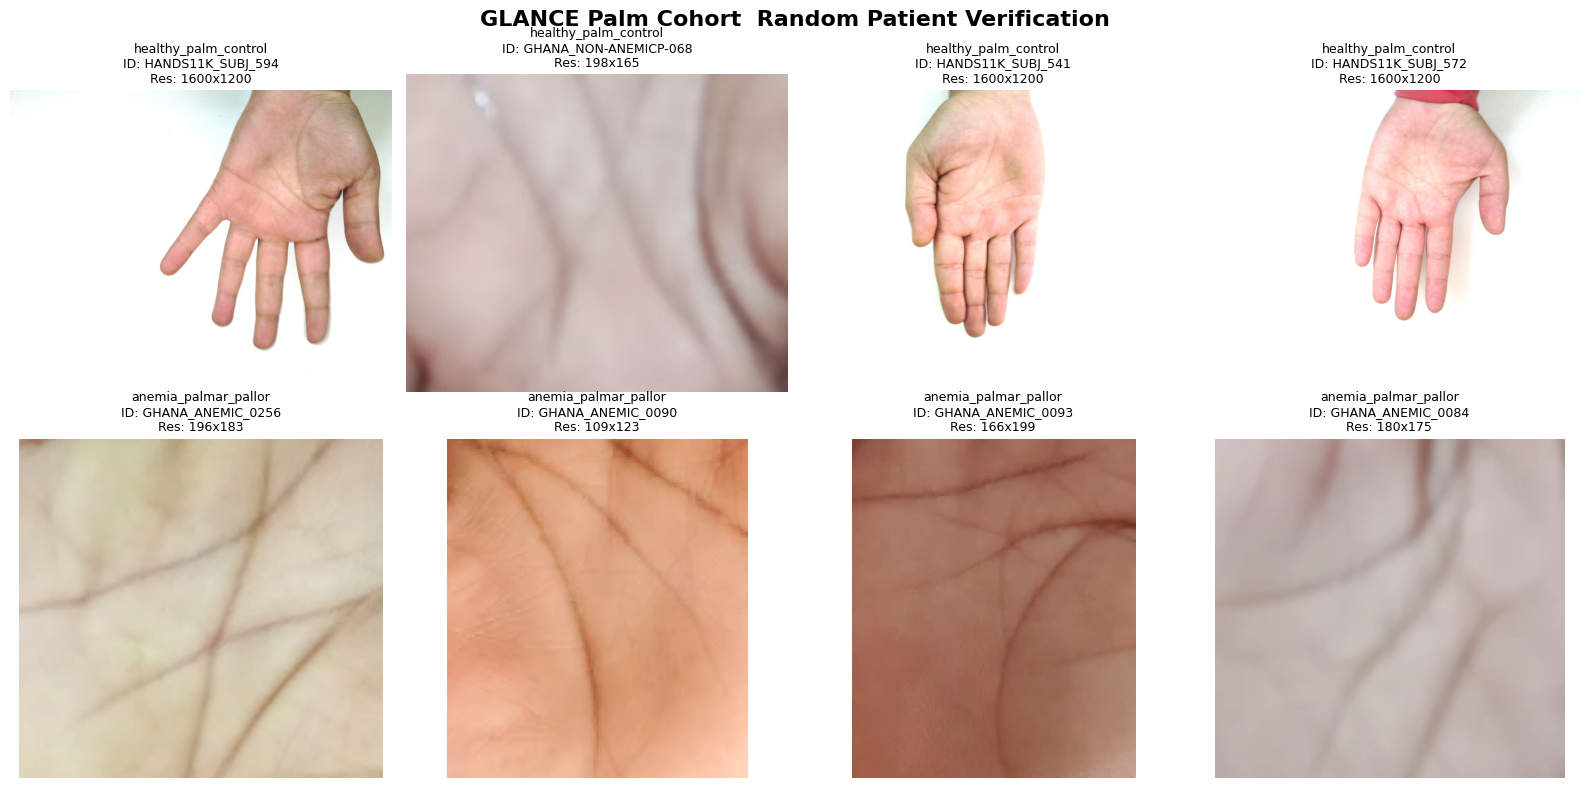

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from pathlib import Path

# 1. Load standardized metadata registry
csv_path = Path("/kaggle/working/ghana_palm_standardized.csv")
assert csv_path.exists(), "Metadata registry CSV not found!"

df = pd.read_csv(csv_path)

# 2. Sample  random images from each class 
SAMPLES_PER_CLASS = 4
classes = df['clinical_condition'].unique()

sampled_df = (
    df.groupby('clinical_condition', group_keys=False)
    .apply(lambda x: x.sample(n=min(len(x), SAMPLES_PER_CLASS), random_state=None))
    .reset_index(drop=True)
)

# 3. Render 2x4 image verification grid
fig, axes = plt.subplots(len(classes), SAMPLES_PER_CLASS, figsize=(16, 8))
fig.suptitle("GLANCE Palm Cohort  Random Patient Verification", fontsize=16, fontweight='bold', y=0.98)

for row_idx, cls_name in enumerate(classes):
    cls_subset = sampled_df[sampled_df['clinical_condition'] == cls_name].reset_index(drop=True)
    
    for col_idx in range(SAMPLES_PER_CLASS):
        ax = axes[row_idx, col_idx] if len(classes) > 1 else axes[col_idx]
        
        if col_idx < len(cls_subset):
            item = cls_subset.iloc[col_idx]
            img_path = Path(item['file_path'])
            
            if img_path.exists():
                with Image.open(img_path) as img:
                    ax.imshow(img)
                title = f"{item['clinical_condition']}\nID: {item['patient_id']}\nRes: {item['width']}x{item['height']}"
                ax.set_title(title, fontsize=9, pad=6)
            else:
                ax.text(0.5, 0.5, "Image Not Found", ha='center', va='center')
        
        ax.axis('off')

plt.tight_layout()
plt.show()